In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
import sys
import os

In [2]:
sys.path.append(os.path.abspath('../src'))
from clustering_viz import plot_elbow_method, plot_3d_clusters, plot_cluster_profiles, plot_2d_segmentation

sns.set_style("whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Carga de datos
df = pd.read_csv('../data/processed/df_cleaned.csv')

In [4]:
print(f"Datos cargados: {df.shape}")
print(f"Modelos presentes: {df['model'].unique()}")

Datos cargados: (28370, 14)
Modelos presentes: ['Chevrolet Silverado 1500' 'Ford F-150' 'Toyota Camry']


In [5]:
features_num = ['price', 'year', 'odometer', 'cylinders_num']
features_cat = ['drive', 'fuel']

print("Variables Numéricas:", features_num)
print("Variables Categóricas:", features_cat)

Variables Numéricas: ['price', 'year', 'odometer', 'cylinders_num']
Variables Categóricas: ['drive', 'fuel']


In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_num),     # Escalar numéricas
        ('cat', OneHotEncoder(), features_cat)       # One-Hot para categóricas
    ]
)

In [7]:
X_processed = preprocessor.fit_transform(df)

In [8]:
print(f"\nDimensiones de la matriz para Clustering: {X_processed.shape}")


Dimensiones de la matriz para Clustering: (28370, 12)


Calculando inercia...


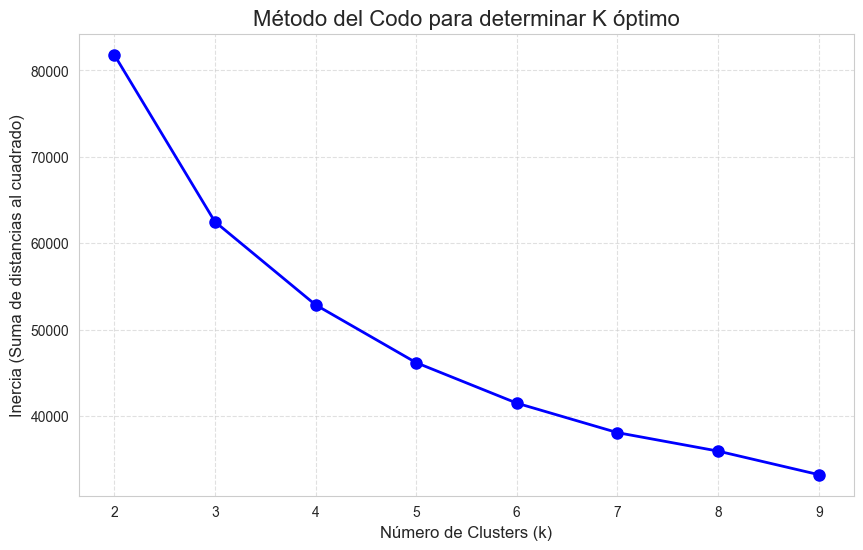

In [9]:
print("Calculando inercia...")
inertia = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_processed)
    inertia.append(kmeans.inertia_)

plot_elbow_method(inertia, k_range)

In [10]:
k_optimo = 4

In [11]:
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_processed)

In [12]:
df['cluster_raw'] = clusters

In [14]:
orden_precio = df.groupby('cluster_raw')['price'].mean().sort_values().index
tier_map = {old_id: new_id for new_id, old_id in enumerate(orden_precio, 1)}

df['tier'] = df['cluster_raw'].map(tier_map)
df.drop(columns=['cluster_raw'], inplace=True)

print("\n--- Distribución de Tiers ---")
print(df['tier'].value_counts().sort_index())


--- Distribución de Tiers ---
tier
1     5502
2     4066
3     8739
4    10063
Name: count, dtype: int64



--- Perfil Medio por Tier ---
        price             year          odometer           cylinders_num  \
         mean   median    mean  median      mean    median          mean   
tier                                                                       
1      8099.2   7900.0  2004.2  2005.0  177906.3  176000.0           7.7   
2     10593.1   8500.0  2010.6  2011.0  112884.9  116006.5           4.2   
3     21353.5  21000.0  2013.0  2013.0  121305.0  120000.0           7.5   
4     37734.5  36000.0  2017.2  2017.0   42230.3   36284.0           7.0   

             
     median  
tier         
1       8.0  
2       4.0  
3       8.0  
4       8.0  


<Figure size 1400x800 with 0 Axes>

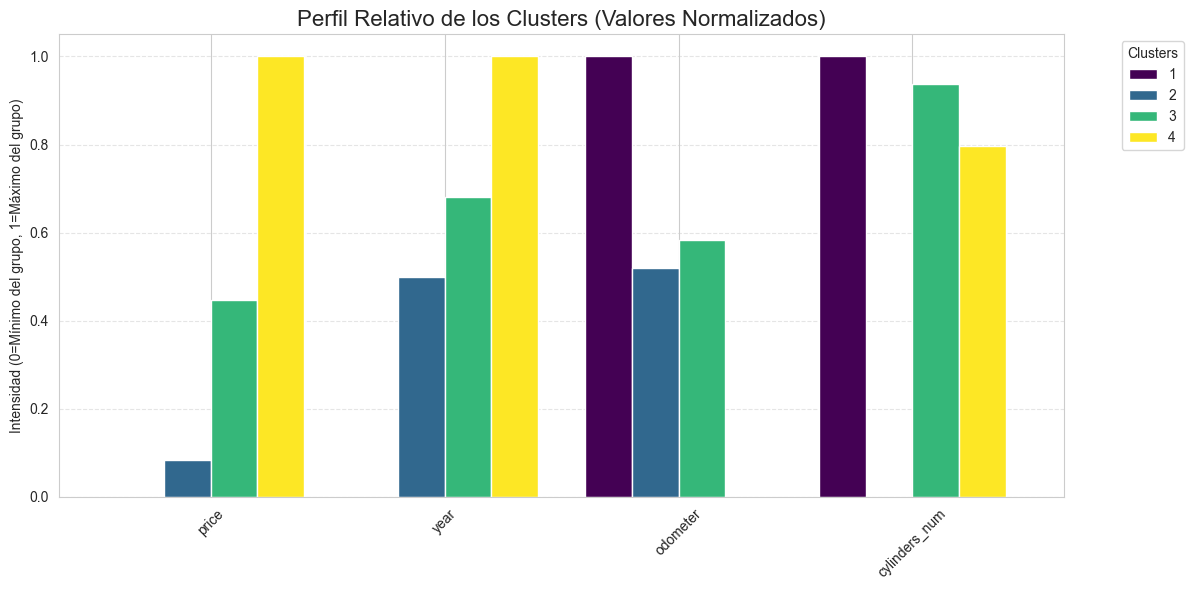

In [15]:
summary = df.groupby('tier')[features_num].agg(['mean', 'median']).round(1)
print("\n--- Perfil Medio por Tier ---")
print(summary)

plot_cluster_profiles(df, 'tier', features_num)

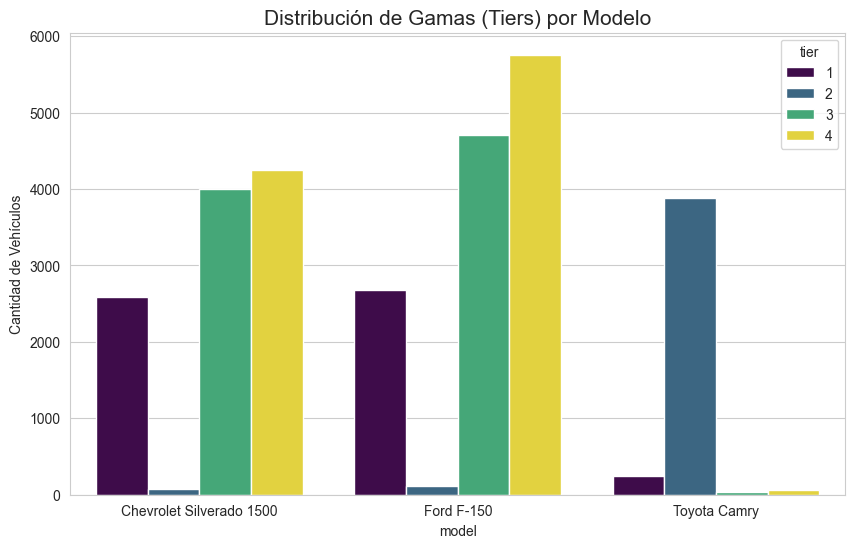

In [16]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='model', hue='tier', palette='viridis')
plt.title('Distribución de Gamas (Tiers) por Modelo', fontsize=15)
plt.ylabel('Cantidad de Vehículos')
plt.show()

In [24]:
target_models = ['Ford F-150', 'Chevrolet Silverado 1500', 'Toyota Camry']

print("--- RADIOGRAFÍA DE TIERS POR MODELO ---")

for model in target_models:
    # 1. Filtramos el dataframe maestro para el modelo actual
    df_subset = df[df['model'] == model]

    # 2. Agrupamos por 'tier'
    resumen = df_subset.groupby('tier').agg({
        'price': ['mean', 'median', 'min', 'max', 'count'],
        'year': ['mean'],
        'odometer': ['mean'],
        # Función lambda segura para sacar la moda
        'condition': lambda x: x.mode().iloc[0] if not x.mode().empty else "Unknown"
    }).round(0)

    # 3. Ordenamos para garantizar que se ve de barato a caro
    resumen = resumen.sort_values(by=('price', 'mean'))

    # 4. Imprimimos con formato bonito
    print(f"\n{'='*60}")
    print(f" MODELO: {model.upper()} (Total: {len(df_subset)} coches)")
    print(f"{'='*60}")
    print(resumen)
    print("\n")

--- RADIOGRAFÍA DE TIERS POR MODELO ---

 MODELO: FORD F-150 (Total: 13252 coches)
        price                                 year  odometer condition
         mean   median    min    max count    mean      mean  <lambda>
tier                                                                  
1      7678.0   7500.0    600  30000  2677  2004.0  173790.0      good
2     12473.0  12900.0    502  27999   115  2011.0  125570.0      good
3     20617.0  20500.0    502  42995  4703  2013.0  123846.0      good
4     37556.0  35998.0  16900  99999  5757  2017.0   44722.0      good



 MODELO: CHEVROLET SILVERADO 1500 (Total: 10899 coches)
        price                                year  odometer condition
         mean   median   min    max count    mean      mean  <lambda>
tier                                                                 
1      8951.0   8500.0   800  32500  2582  2004.0  181158.0      good
2      9762.0   9399.0   702  29995    69  2010.0  113487.0      good
3     22307

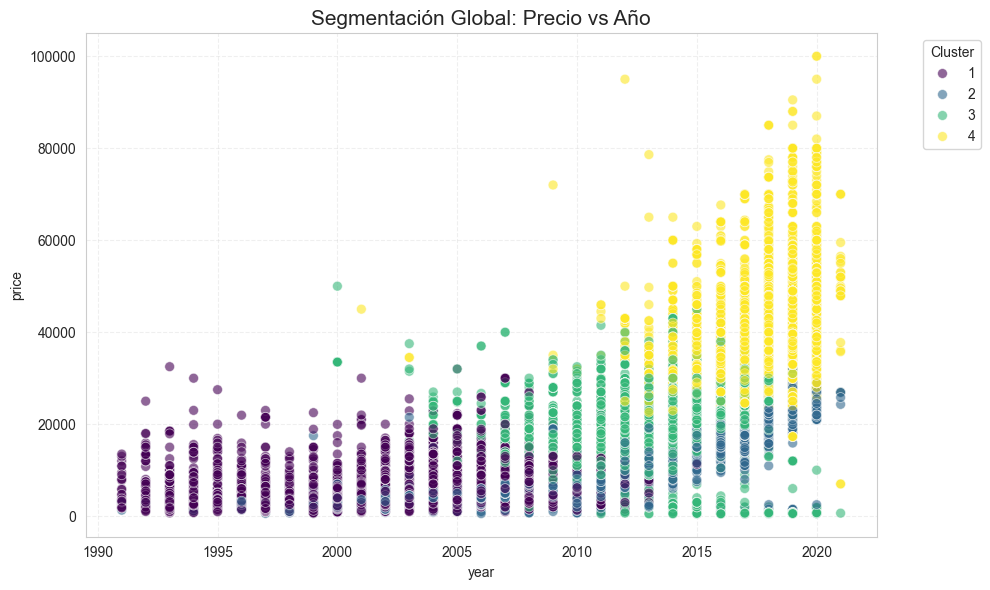

In [17]:
plot_2d_segmentation(df, 'year', 'price', 'tier', 'Segmentación Global: Precio vs Año')

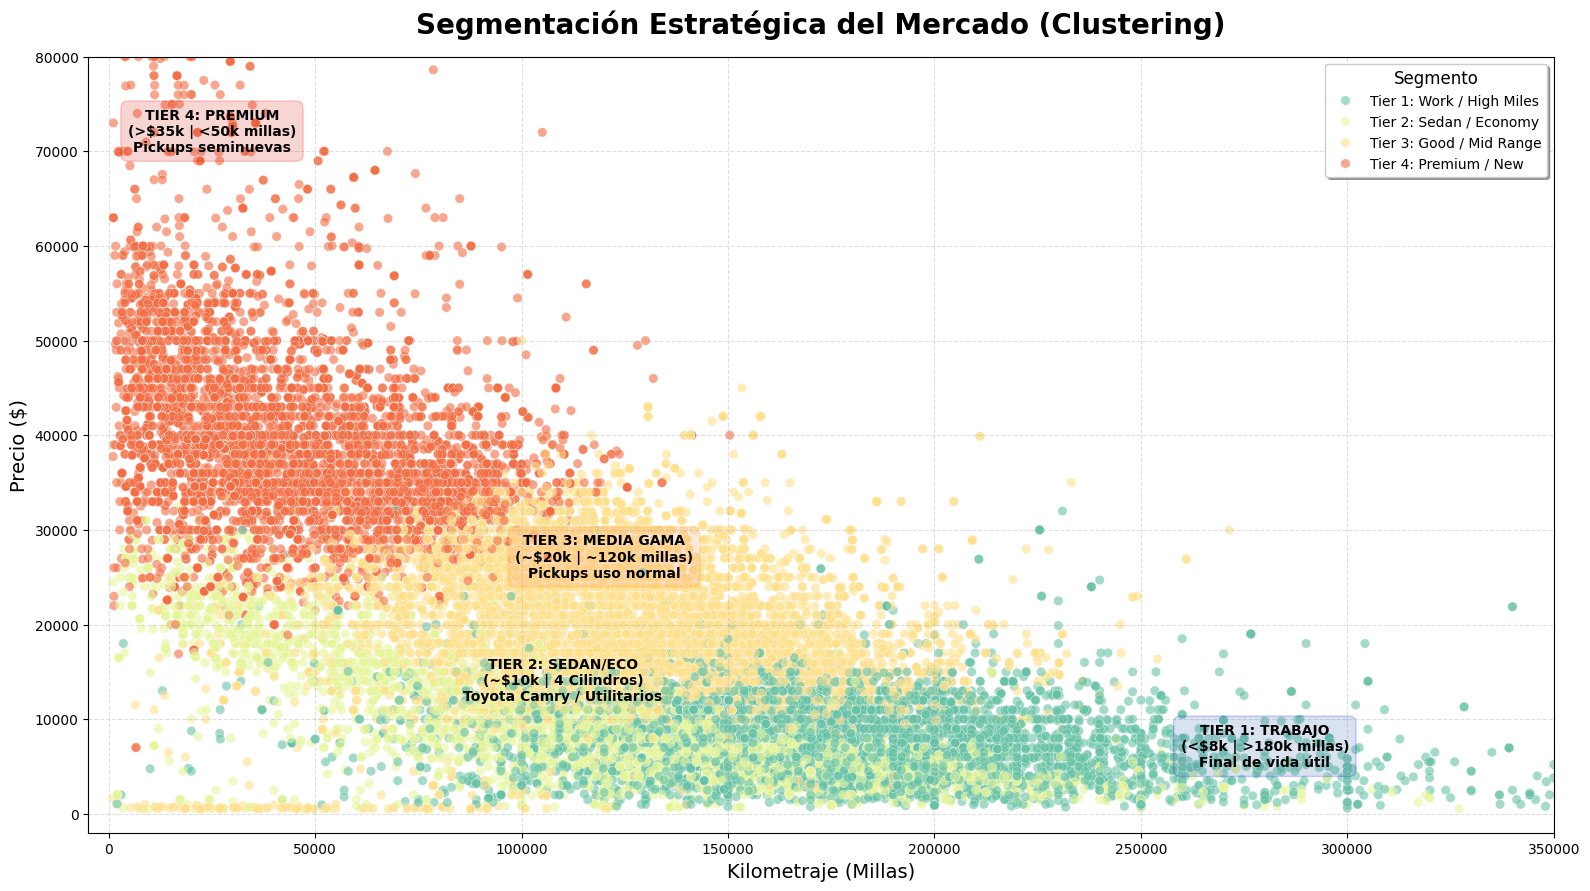

In [26]:
tier_labels = {
    1: 'Tier 1: Work / High Miles',   # Barato, mucha milla
    2: 'Tier 2: Sedan / Economy',     # El grupo del Camry (4 cil)
    3: 'Tier 3: Good / Mid Range',    # Camioneta usada en buen estado
    4: 'Tier 4: Premium / New'        # Lujo y seminuevo
}

# Mapeamos
df['tier_cat'] = df['tier'].map(tier_labels)

# Orden para la leyenda
order_tiers = [tier_labels[1], tier_labels[2], tier_labels[3], tier_labels[4]]

# 2. GRÁFICO
plt.figure(figsize=(16, 9))

sns.scatterplot(
    data=df,
    x='odometer',
    y='price',
    hue='tier_cat',
    hue_order=order_tiers,
    palette='Spectral_r',
    alpha=0.6,
    s=45,
    edgecolor='w',
    linewidth=0.3
)

# 3. DECORACIÓN
plt.title('Segmentación Estratégica del Mercado (Clustering)', fontsize=20, fontweight='bold', y=1.02)
plt.xlabel('Kilometraje (Millas)', fontsize=14)
plt.ylabel('Precio ($)', fontsize=14)

plt.xlim(-5000, 350000)
plt.ylim(-2000, 80000)

plt.legend(title='Segmento', title_fontsize='12', loc='upper right', frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.4)

plt.text(25000, 70000,
         'TIER 4: PREMIUM\n(>$35k | <50k millas)\nPickups seminuevas',
         color='black', fontsize=10, ha='center', fontweight='bold',
         bbox=dict(facecolor='#d73027', alpha=0.2, edgecolor='red', boxstyle='round,pad=0.5'))

plt.text(120000, 25000,
         'TIER 3: MEDIA GAMA\n(~$20k | ~120k millas)\nPickups uso normal',
         color='black', fontsize=10, ha='center', fontweight='bold',
         bbox=dict(facecolor='#fc8d59', alpha=0.2, edgecolor='orange', boxstyle='round,pad=0.5'))

plt.text(110000, 12000,
         'TIER 2: SEDAN/ECO\n(~$10k | 4 Cilindros)\nToyota Camry / Utilitarios',
         color='black', fontsize=10, ha='center', fontweight='bold',
         bbox=dict(facecolor='#fee090', alpha=0.2, edgecolor='gold', boxstyle='round,pad=0.5'))

plt.text(280000, 5000,
         'TIER 1: TRABAJO\n(<$8k | >180k millas)\nFinal de vida útil',
         color='black', fontsize=10, ha='center', fontweight='bold',
         bbox=dict(facecolor='#4575b4', alpha=0.2, edgecolor='blue', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

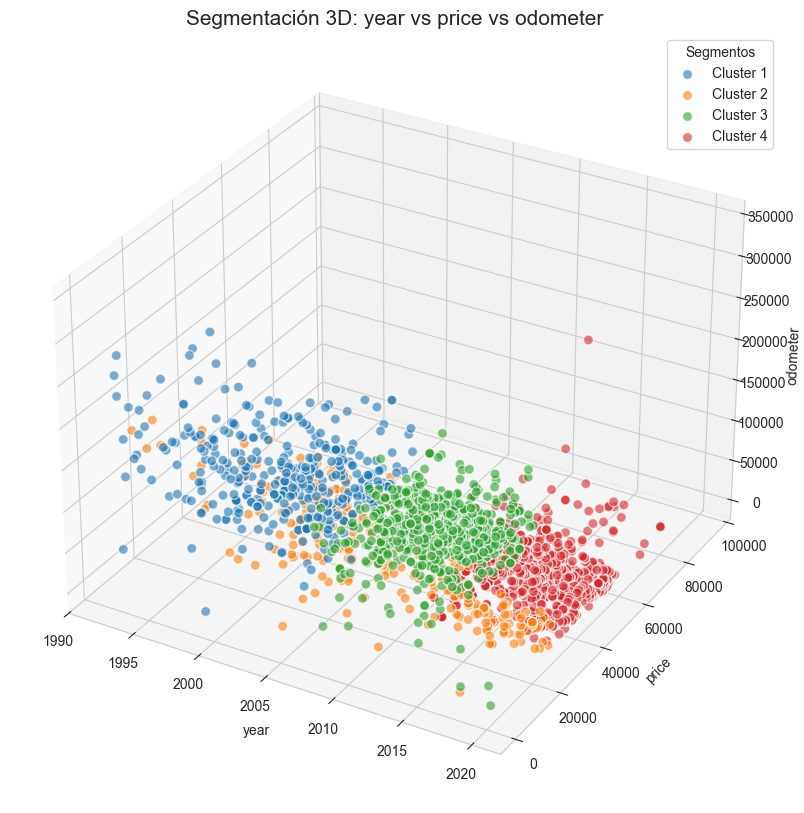

In [18]:
df_sample = df.sample(min(2000, len(df)))
plot_3d_clusters(df_sample, 'year', 'price', 'odometer', 'tier')

In [20]:
sns.set_style("whitegrid")
modelos = ['Ford F-150', 'Chevrolet Silverado 1500', 'Toyota Camry']
colores_tiers = 'viridis'

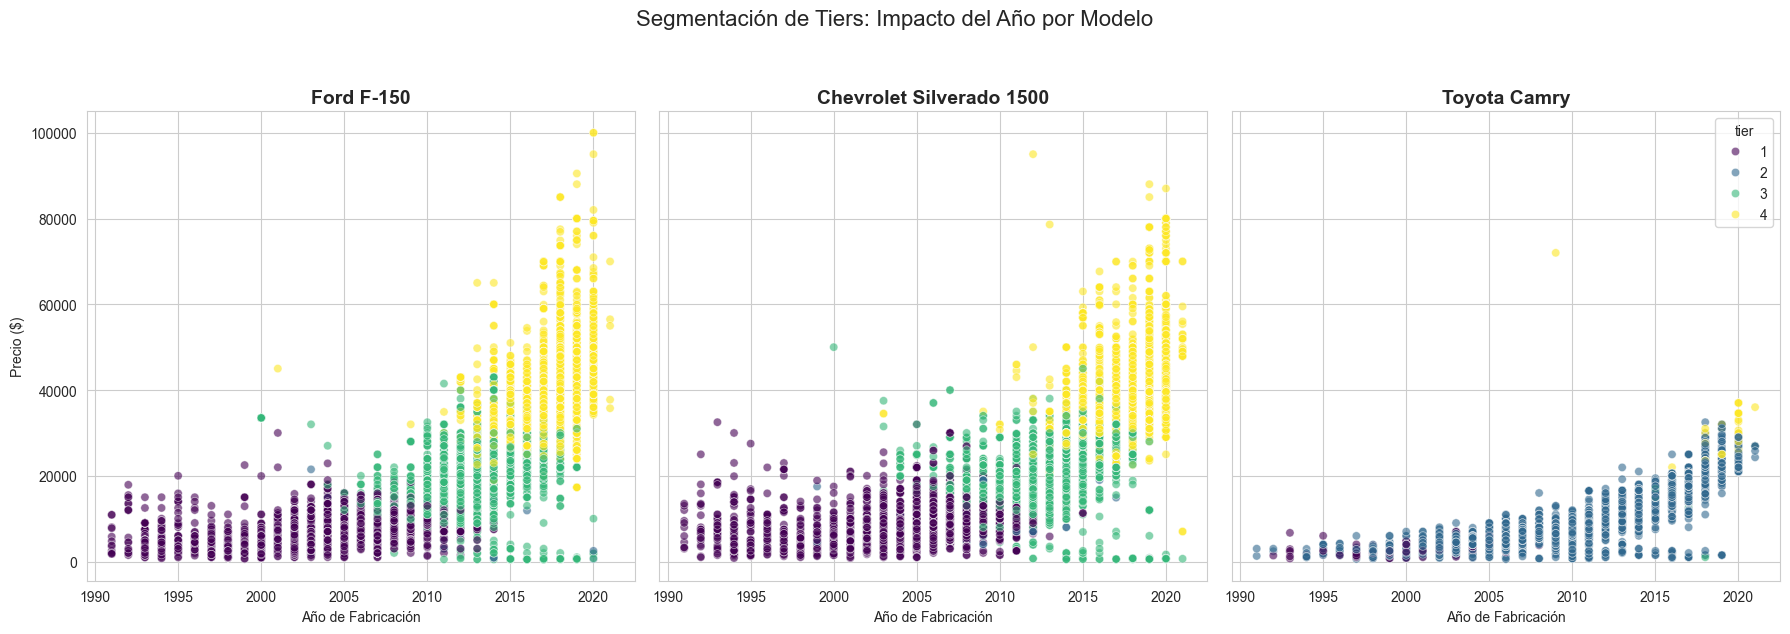

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, modelo in enumerate(modelos):
    # Filtramos datos del modelo actual
    df_model = df[df['model'] == modelo]

    sns.scatterplot(
        data=df_model,
        x='year',
        y='price',
        hue='tier',
        palette=colores_tiers,
        alpha=0.6,
        ax=axes[i],
        legend=(i==2)
    )

    axes[i].set_title(f'{modelo}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Año de Fabricación')
    if i == 0:
        axes[i].set_ylabel('Precio ($)')
    else:
        axes[i].set_ylabel('')

plt.suptitle('Segmentación de Tiers: Impacto del Año por Modelo', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

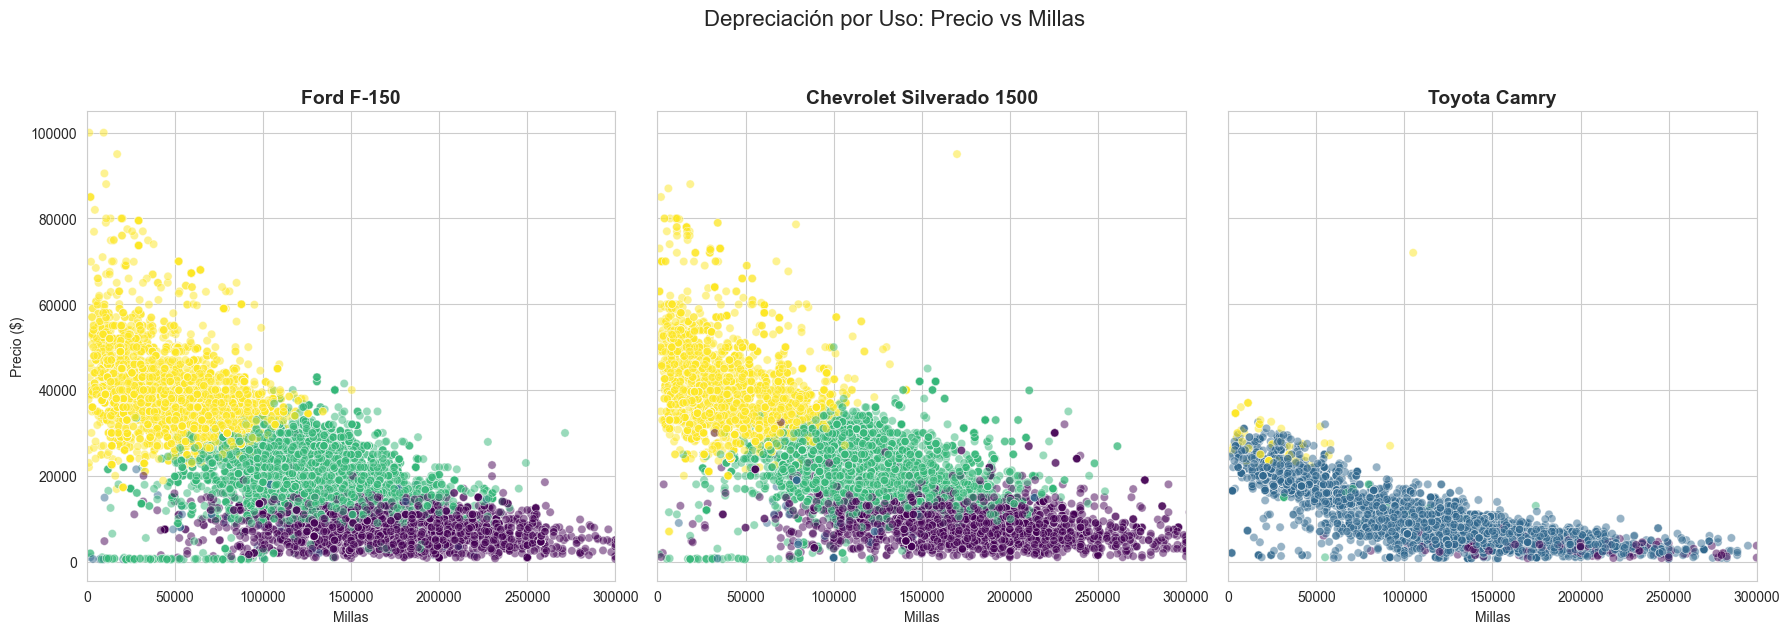

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, modelo in enumerate(modelos):
    df_model = df[df['model'] == modelo]

    sns.scatterplot(
        data=df_model,
        x='odometer',
        y='price',
        hue='tier',
        palette=colores_tiers,
        alpha=0.5,
        ax=axes[i],
        legend=False
    )

    axes[i].set_title(f'{modelo}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Millas')
    axes[i].set_xlim(0, 300000) # Limitamos eje X para ver mejor la mayoría
    if i == 0:
        axes[i].set_ylabel('Precio ($)')
    else:
        axes[i].set_ylabel('')

plt.suptitle('Depreciación por Uso: Precio vs Millas', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

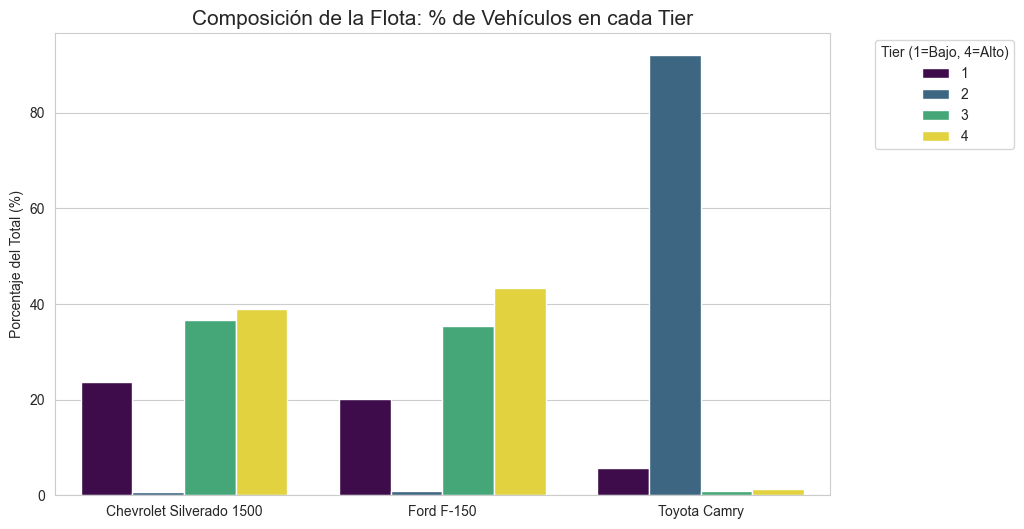

In [23]:
plt.figure(figsize=(10, 6))

# Calculamos porcentajes para que sea justo comparar (ya que puede haber más F-150 que Camrys)
df_counts = df.groupby(['model', 'tier']).size().reset_index(name='counts')
df_totals = df.groupby('model')['tier'].count().reset_index(name='total')
df_props = df_counts.merge(df_totals, on='model')
df_props['percentage'] = df_props['counts'] / df_props['total'] * 100

sns.barplot(
    data=df_props,
    x='model',
    y='percentage',
    hue='tier',
    palette=colores_tiers
)

plt.title('Composición de la Flota: % de Vehículos en cada Tier', fontsize=15)
plt.ylabel('Porcentaje del Total (%)')
plt.xlabel('')
plt.legend(title='Tier (1=Bajo, 4=Alto)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [19]:
df.to_csv('../data/processed/df_master_clustered.csv', index=False)
print("✅ Clustering completado y guardado.")

✅ Clustering completado y guardado.
